# Installing dependencies and libraries and dataset


In [ ]:
!pip install tensorflow==2.13.0
!pip install matplotlib
!pip install nltk
!pip install wget

In [3]:
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Embedding, LSTM, Dense, AdditiveAttention, Input, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical
import numpy as np
import os
import matplotlib.pyplot as plt
import nltk
import glob
import wget
import zipfile
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
# Flickr8k captions
!wget -O Flickr8k_text.zip https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip
with zipfile.ZipFile('Flickr8k_text.zip', 'r') as zip_ref:
    zip_ref.extractall('data/')

# Flickr8k images (full set ~8k images, but we download only the first 500 manually)
!wget -O Flickr8k_Dataset.zip https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip
with zipfile.ZipFile('Flickr8k_Dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('data/')



In [7]:
# Keep only first 500 images
image_files = glob.glob('data/Flicker8k_Dataset/*.jpg')[:500]
os.makedirs('data/images', exist_ok=True)
for f in image_files:
    os.rename(f, f'data/images/{os.path.basename(f)}')

# Preprocessing

In [8]:
# Read captions
captions_dict = {}
with open('data/Flickr8k.token.txt', 'r') as f:
    for line in f.readlines():
        image_id, caption = line.strip().split('\t')
        image_name = image_id.split('#')[0]
        if image_name in [os.path.basename(x) for x in image_files]:
            captions_dict.setdefault(image_name, []).append('<start> ' + caption + ' <end>')

# Flatten captions for tokenizer
all_captions = [cap for caps in captions_dict.values() for cap in caps]
tokenizer = Tokenizer(num_words=5000, oov_token='<unk>')
tokenizer.fit_on_texts(all_captions)
tokenizer.word_index['<pad>'] = 0
tokenizer.index_word[0] = '<pad>'
vocab_size = len(tokenizer.word_index)
max_length = max(len(c.split()) for c in all_captions)

print("Vocabulary Size:", vocab_size)
print("Max Caption Length:", max_length)

Vocabulary Size: 2237
Max Caption Length: 34


In [ ]:
image_model = InceptionV3(weights='imagenet')
new_input = image_model.input
hidden_layer = image_model.layers[-2].output
image_features_extract_model = Model(new_input, hidden_layer)

def preprocess_image(image_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (299, 299))
    img = tf.keras.applications.inception_v3.preprocess_input(img)
    return img, image_path

def extract_features(image_paths):
    features = {}
    for img_path in image_paths:
        img, path = preprocess_image(img_path)
        img = tf.expand_dims(img, axis=0)
        feature = image_features_extract_model(img)
        features[os.path.basename(path)] = feature
    return features

# Extract features for 500 images
photo_features = extract_features(glob.glob('data/images/*.jpg'))
print("Features extracted for", len(photo_features), "images")

Features extracted for 500 images


In [11]:
def create_sequences(tokenizer, max_length, captions_list, photo_features):
    X1, X2, y = [], [], []
    for img_name, captions in captions_list.items():
        feature = photo_features[img_name].numpy().squeeze()
        for caption in captions:
            seq = tokenizer.texts_to_sequences([caption])[0]
            for i in range(1, len(seq)):
                in_seq, out_seq = seq[:i], seq[i]
                in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
                out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]
                X1.append(feature)
                X2.append(in_seq)
                y.append(out_seq)
    return np.array(X1), np.array(X2), np.array(y)

X1, X2, y = create_sequences(tokenizer, max_length, captions_dict, photo_features)
print("Training sequences:", X1.shape, X2.shape, y.shape)

Training sequences: (29529, 2048) (29529, 34) (29529, 2237)


In [14]:
from tensorflow.keras.layers import Lambda


# Training. Can be ignored for testing

In [24]:
from tensorflow.keras.layers import Input, Dense, Embedding, LSTM, Lambda, Concatenate
from tensorflow.keras.layers import AdditiveAttention

units = 512  # LSTM hidden size
embedding_dim = 256  # word embedding size

# --- Encoder ---
image_features_input = Input(shape=(2048,))
# Match LSTM units to avoid dimension mismatch
encoder_output = Dense(units, activation='relu')(image_features_input)

# --- Decoder ---
seq_input = Input(shape=(max_length,))
embedding = Embedding(vocab_size, embedding_dim, mask_zero=True)(seq_input)

# LSTM: return_sequences=False for single-step prediction
decoder_output, _, _ = LSTM(units, return_sequences=False, return_state=True)(
    embedding, initial_state=[encoder_output, encoder_output]
)

# --- Attention ---
# Use Lambda to expand dims (KerasTensor compatible)
encoder_output_reshaped = Lambda(lambda x: tf.expand_dims(x, axis=1))(encoder_output)
decoder_output_exp = Lambda(lambda x: tf.expand_dims(x, axis=1))(decoder_output)
attention = AdditiveAttention()([decoder_output_exp, encoder_output_reshaped])
attention_squeezed = Lambda(lambda x: tf.squeeze(x, axis=1))(attention)

# Concatenate attention context with LSTM output
decoder_concat = Concatenate(axis=-1)([decoder_output, attention_squeezed])


# --- Dense layers ---
dense1 = Dense(512, activation='relu')(decoder_concat)
output = Dense(vocab_size, activation='softmax')(dense1)

# --- Model ---
model = tf.keras.Model(inputs=[image_features_input, seq_input], outputs=output)
model.compile(loss='categorical_crossentropy', optimizer='adam')

model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_19      │ (None, 34)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_18      │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_8         │ (None, 34, 256)   │    572,672 │ input_layer_19[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 512)       │  1,049,088 │ input_layer_18[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_9 (LSTM)       │ [(None, 512),     │  1,574,912 │ embedding_8[0][0… │
│                     │ (None, 512),      │            │ dense_16[0][0],   │
│                     │ (None, 512)]      │            │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_12 (Lambda)  │ (None, 1, 512)    │          0 │ lstm_9[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_11 (Lambda)  │ (None, 1, 512)    │          0 │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ additive_attention… │ (None, 1, 512)    │        512 │ lambda_12[0][0],  │
│ (AdditiveAttention) │                   │            │ lambda_11[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_13 (Lambda)  │ (None, 512)       │          0 │ additive_attenti… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_12      │ (None, 1024)      │          0 │ lstm_9[0][0],     │
│ (Concatenate)       │                   │            │ lambda_13[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 512)       │    524,800 │ concatenate_12[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 2237)      │  1,147,581 │ dense_17[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,869,565 (18.58 MB)

 Trainable params: 4,869,565 (18.58 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit([X1, X2], y, batch_size=256, epochs=3)
os.makedirs('models', exist_ok=True)

In [29]:
model.save_weights('models/image_captioning.weights.h5')
print("Model weights saved at models/image.captioning_weights.h5")

Model weights saved at models/image.captioning_weights.h5


# Start testing from here after having the dataset

Remove the comment

In [ ]:
#model.load_weights("image_captioning.weights.h5")

In [ ]:
def generate_caption(image_path, tokenizer, max_length):
    feature = extract_features([image_path])[os.path.basename(image_path)]
    in_text = '<start>'
    for i in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length)
        yhat = model.predict([feature.numpy(), sequence], verbose=0)
        yhat = np.argmax(yhat[0])
        word = tokenizer.index_word.get(yhat, None)
        if word is None or word == '<end>':
            break
        in_text += ' ' + word
    return in_text.replace('<start> ', '')

# Test on random image
caption = generate_caption('data/images/' + os.listdir('data/images')[15], tokenizer, 7)
print("Generated Caption:", caption)

Generated Caption: a dog is running through the grass


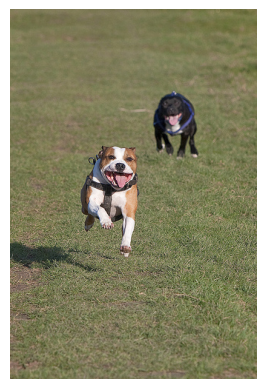

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Get the image in the folder
image_files = os.listdir('data/images/')
image_path = os.path.join('data/images', image_files[15])

# Load and show the image
img = mpimg.imread(image_path)
plt.imshow(img)
plt.axis('off')  # hide axes
plt.show()